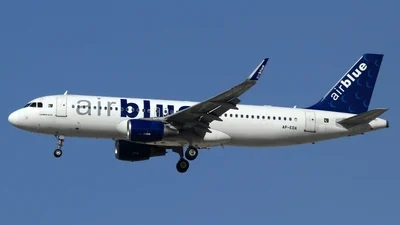

# 📊 **Descriptive Analysis of Flight Price Dataset**

## 📁 **Dataset Overview**

The dataset contains **10,683 flight records** with details such as airline, journey date, source, destination, route, departure/arrival time, duration, number of stops, and ticket price.

---

## 🧱 **1. Column-wise Summary**

| Column | Type | Description |
|-------|------|-------------|
| **Airline** | Categorical | Airline operating the flight (12 unique airlines). |
| **Date_of_Journey** | Categorical | Date of travel (string format). |
| **Source** | Categorical | Starting city (5 unique sources). |
| **Destination** | Categorical | Destination city (6 unique destinations). |
| **Route** | Categorical | Full route including stops (128 unique paths). |
| **Dep_Time** | Categorical | Departure time. |
| **Arrival_Time** | Categorical | Arrival time (often includes next-day info). |
| **Duration** | Categorical | Total duration (string format, not numeric). |
| **Total_Stops** | Categorical | Number of stops (non-stop/1 stop/2 stops/etc.). |
| **Additional_Info** | Categorical | Meal preferences, baggage info, etc. |
| **Price** | Numeric | Ticket price in INR. |

---

## 📉 **2. Statistical Summary of Price**

| Metric | Value |
|--------|--------|
| **Count** | 10,683 |
| **Mean Price** | ₹9,087.06 |
| **Std Dev** | ₹4,611.36 |
| **Minimum Price** | ₹1,759 |
| **25th Percentile** | ₹5,277 |
| **Median (50%)** | ₹8,372 |
| **75th Percentile** | ₹12,373 |
| **Maximum Price** | ₹79,512 |

**Interpretation:**
- Most flights cost between **₹5,277 and ₹12,373**.
- Few flights are extremely expensive (up to **₹79,512**).

---

## ✈️ **3. Categorical Feature Insights**

### **Airline**
- 12 airlines in the dataset (IndiGo, Air India, Jet Airways, SpiceJet, Vistara, etc.).

### **Source Cities**
- 5 main sources: **Banglore, Delhi, Kolkata, Mumbai, Chennai**.

### **Destination Cities**
- 6 destinations: **New Delhi, Banglore, Cochin, Hyderabad, Kolkata, Delhi**.

### **Total Stops**
Categories include:
- non-stop  
- 1 stop  
- 2 stops  
- 3+ stops  

---

## ⏱ **4. Duration Insights**

- Duration is a string (e.g., “2h 50m”), not numeric.
- Shortest flights: ~1 hour  
- Longest flights: **20+ hours** (due to many stops)

---

## 🛣 **5. Route Complexity**

- **128 unique routes**
- Flights vary from direct flights to multi-stop routes involving multiple cities.

---

## 📌 **6. Sample Rows**

| Airline | Date | Source | Destination | Route | Dep | Arrival | Duration | Stops | Info | Price |
|--------|-------|---------|---------------|--------|-------|----------|----------|------------|---------|--------|
| IndiGo | 24/03/2019 | Banglore | New Delhi | BLR → DEL | 22:20 | 01:10 (next day) | 2h 50m | non-stop | No info | 3897 |
| Air India | 1/05/2019 | Kolkata | Banglore | CCU → IXR → BBI → BLR | 05:50 | 13:15 | 7h 25m | 2 stops | No info | 7662 |
| Jet Airways | 9/06/2019 | Delhi | Cochin | DEL → LKO → BOM → COK | 09:25 | next day | 19h | 2 stops | No info | 13882 |

---

## 🧭 **7. Key Observations**

- High variation in **ticket prices**.
- Majority of columns are **categorical**, needing encoding for ML.
- Duration, arrival time, and route require **cleaning & preprocessing**.
- Dataset is suitable for **flight price prediction**.

---


# 1) Overall Data Analysis


## **1.1) Importing the necessary Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 1.2) **Loading the data**

In [ ]:
!git clone 'https://github.com/HarshvardhanSingh-13/Datasets'

fatal: destination path 'Datasets' already exists and is not an empty directory.


In [ ]:
df = pd.read_excel('/content/Datasets/Flight Prices/flight_price.xlsx')

## **1.3) Initial Data Inspection**



*   To check data types and null values







In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


*   For statistical summary of numerical columns




In [ ]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


*   To see the first 5 rows




In [ ]:
df.head(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


*   To see number of rows/columns







In [ ]:
df.shape

(10683, 11)

##  1.4)Handling Missing Values (NaN)

*   count of missing values



In [ ]:
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


*   Removing Null Values



In [ ]:
df.dropna(inplace=True)

# **2) Column Wise Exploration**

*   columns in the data frames



In [ ]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

##**2.1) Airline Column Exploration**

In [ ]:
df['Airline']

,Airline
0,IndiGo
1,Air India
2,Jet Airways
3,IndiGo
4,IndiGo
...,...
10678,Air Asia
10679,Air India
10680,Jet Airways
10681,Vistara


## count of each airline

In [ ]:
df['Airline'].value_counts()

,count
Airline,
Jet Airways,3849
IndiGo,2053
Air India,1751
Multiple carriers,1196
SpiceJet,818
Vistara,479
Air Asia,319
GoAir,194
Multiple carriers Premium economy,13


## All the entries of "Air india" Airline ✈

In [ ]:
df[df['Airline']=='Air India']

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
10,Air India,1/06/2019,Delhi,Cochin,DEL → BLR → COK,09:45,23:00,13h 15m,1 stop,No info,8907
12,Air India,24/06/2019,Chennai,Kolkata,MAA → CCU,11:40,13:55,2h 15m,non-stop,No info,4667
15,Air India,3/03/2019,Delhi,Cochin,DEL → AMD → BOM → COK,16:40,19:15 04 Mar,26h 35m,2 stops,No info,14011
18,Air India,12/06/2019,Delhi,Cochin,DEL → CCU → BOM → COK,20:15,19:15 13 Jun,23h,2 stops,No info,13381
...,...,...,...,...,...,...,...,...,...,...,...
10670,Air India,12/05/2019,Kolkata,Banglore,CCU → IXR → DEL → BLR,05:50,23:15,17h 25m,2 stops,No info,11411
10671,Air India,6/06/2019,Mumbai,Hyderabad,BOM → HYD,21:05,22:25,1h 20m,non-stop,No info,3100
10675,Air India,9/06/2019,Mumbai,Hyderabad,BOM → HYD,06:20,07:40,1h 20m,non-stop,No info,3100
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145


## No of entries of "air india" airline

In [ ]:
len(df[df['Airline']=='Air India'])

1751

## unique airline available in dataframe

In [ ]:
df['Airline'].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

## count of unique airline

In [ ]:
df['Airline'].nunique()

12

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Date_of_Journey  10682 non-null  object
 2   Source           10682 non-null  object
 3   Destination      10682 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10682 non-null  object
 6   Arrival_Time     10682 non-null  object
 7   Duration         10682 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10682 non-null  object
 10  Price            10682 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 1001.4+ KB


# 2.2) Date of journey column exploration

In [ ]:
df['Date_of_Journey']

,Date_of_Journey
0,24/03/2019
1,1/05/2019
2,9/06/2019
3,12/05/2019
4,01/03/2019
...,...
10678,9/04/2019
10679,27/04/2019
10680,27/04/2019
10681,01/03/2019


### count of each date in dataframes
*   highest no of airline booked in 18 th may



In [ ]:
df['Date_of_Journey'].value_counts()

,count
Date_of_Journey,
18/05/2019,504
6/06/2019,503
21/05/2019,497
9/06/2019,495
12/06/2019,493
9/05/2019,484
21/03/2019,423
15/05/2019,405
27/05/2019,382


## **Cleaning in Date of Journey**


### DATE,MONTH ,YEAR Extraction FROM DATE OF JOURNEY





In [ ]:
Date=[]
Month=[]
Year=[]
for i in df['Date_of_Journey']:
  Date.append(i.split('/')[0])
  Month.append(i.split('/')[1])
  Year.append(i.split('/')[2])


## creating a new column in dataframe and insert date month year

In [ ]:
df['Date']=Date
df['Month']=Month
df['Year']=Year

In [ ]:
df['Date']=df['Date'].astype(int)
df['Month']=df['Month'].astype(int)
df['Year']=df['Year'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Date_of_Journey  10682 non-null  object
 2   Source           10682 non-null  object
 3   Destination      10682 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10682 non-null  object
 6   Arrival_Time     10682 non-null  object
 7   Duration         10682 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10682 non-null  object
 10  Price            10682 non-null  int64 
 11  Date             10682 non-null  int64 
 12  Month            10682 non-null  int64 
 13  Year             10682 non-null  int64 
dtypes: int64(4), object(10)
memory usage: 1.2+ MB


## 2.3 **source and destination  column exploration**



In [ ]:
df['Source']

,Source
0,Banglore
1,Kolkata
2,Delhi
3,Kolkata
4,Banglore
...,...
10678,Kolkata
10679,Kolkata
10680,Banglore
10681,Banglore


### count of each source of dataframe

In [ ]:
df['Source'].value_counts()

,count
Source,
Delhi,4536
Kolkata,2871
Banglore,2197
Mumbai,697
Chennai,381


### count of each destination in dataframe



In [ ]:
df['Destination'].value_counts()

,count
Destination,
Cochin,4536
Banglore,2871
Delhi,1265
New Delhi,932
Hyderabad,697
Kolkata,381


### replace new delhi to delhi

In [ ]:
df['Destination']=df['Destination'].str.replace('New Delhi','Delhi')

### check count of each destination

In [ ]:
df['Destination'].value_counts().sort_values(ascending=True)

,count
Destination,
Kolkata,381
Hyderabad,697
Delhi,2197
Banglore,2871
Cochin,4536


In [ ]:
df.tail(55)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
10628,SpiceJet,9/05/2019,Kolkata,Banglore,CCU → IXB → BLR,15:55,21:25,5h 30m,1 stop,No info,8224,9,5,2019
10629,Multiple carriers,3/03/2019,Delhi,Cochin,DEL → HYD → COK,07:05,16:10,9h 5m,1 stop,No info,7905,3,3,2019
10630,Jet Airways,24/03/2019,Kolkata,Banglore,CCU → BOM → BLR,16:55,19:40 25 Mar,26h 45m,1 stop,In-flight meal not included,11134,24,3,2019
10631,IndiGo,15/05/2019,Delhi,Cochin,DEL → BLR → COK,02:00,07:45,5h 45m,1 stop,No info,6037,15,5,2019
10632,Jet Airways,6/06/2019,Kolkata,Banglore,CCU → DEL → BLR,17:00,10:55 07 Jun,17h 55m,1 stop,No info,12692,6,6,2019
10633,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,18:15,01:30 28 May,7h 15m,1 stop,In-flight meal not included,7308,27,5,2019
10634,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 07 Jun,26h 55m,2 stops,In-flight meal not included,11733,6,6,2019
10635,Jet Airways,1/06/2019,Delhi,Cochin,DEL → BOM → COK,22:50,12:35 02 Jun,13h 45m,1 stop,No info,14714,1,6,2019
10636,Jet Airways,15/05/2019,Kolkata,Banglore,CCU → BOM → BLR,06:30,12:00,5h 30m,1 stop,No info,14388,15,5,2019
10637,Jet Airways,24/04/2019,Banglore,Delhi,BLR → DEL,18:55,22:00,3h 5m,non-stop,No info,7229,24,4,2019


# *2.4) Duration Column Exploration *

In [ ]:
df['Duration']

,Duration
0,2h 50m
1,7h 25m
2,19h
3,5h 25m
4,4h 45m
...,...
10678,2h 30m
10679,2h 35m
10680,3h
10681,2h 40m


In [ ]:
df['Duration'].sort_values(ascending=True)

,Duration
3701,10h
2995,10h
8012,10h
3112,10h
84,10h
...,...
4307,9h 5m
2219,9h 5m
10179,9h 5m
1494,9h 5m


### checking 5m duration in thedata set

In [ ]:
df[df['Duration']=='5m']

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
6474,Air India,6/03/2019,Mumbai,Hyderabad,BOM → GOI → PNQ → HYD,16:50,16:55,5m,2 stops,No info,17327,6,3,2019


### updating the data set

In [ ]:
df=df[df['Duration']!='5m']

### extrating the hour column from the data set

In [ ]:
Hours=[]
for i in df['Duration']:
  Hours.append(i.split(" ")[0].split('h')[0])


In [ ]:
df['Hour']=Hours

In [ ]:
df['Hour']=df['Hour'].astype(int)

### extracting the min column from the duration column

In [ ]:
df['min']=df['Duration'].str.split(" ").str[1].str.split('m').str[0].fillna(0).astype(int)

In [ ]:
df['journey_time']=df['Hour']*60 + df['min']

In [ ]:
df['Duration']

,Duration
0,2h 50m
1,7h 25m
2,19h
3,5h 25m
4,4h 45m
...,...
10678,2h 30m
10679,2h 35m
10680,3h
10681,2h 40m


# ** Extarcting the data by basic PYTHON **

In [ ]:
mins=[]
for i in df['Duration']:
   if len(i.split(" ")) == 1:
    print(i.split('h')[0])
   elif (len(i.split(" ")) == 2):
    print(i.split('h')[0],end=" ")
    print(i.split(' ')[1].split('m')[0])

2 50
7 25
19
5 25
4 45
2 25
15 30
21 5
25 30
7 50
13 15
2 35
2 15
12 10
2 35
26 35
4 30
22 35
23
20 35
5 10
15 20
2 50
2 55
13 20
15 10
5 45
5 55
2 50
2 15
2 15
13 25
2 50
22
5 30
10 25
5 15
2 30
6 15
11 55
11 5
8 30
22 5
2 45
12
2 50
2 50
2 15
16 5
19 55
3 15
25 20
2 50
3
2 50
16 15
15 5
2 15
6 30
25 5
12 25
27 20
10 15
10 30
2 15
10 25
2 50
1 30
13 20
2 15
1 25
26 30
7 20
13 30
5
2 45
2 50
1 30
19 5
2 15
14 50
2 40
22 10
9 35
10
21 20
5 25
18 45
12 20
18
9 15
11 5
17 30
13 20
2 35
2 25
2 40
3
1 25
16 35
12 20
12 15
7 30
24
2 45
8 55
7 10
14 30
30 20
19 55
15
2 55
12 45
10 10
5 55
15 25
16 5
10 10
2 40
11 55
2 40
1 25
14 5
20 15
2 25
23 10
18 10
16
2 50
2 20
8
16 55
3 10
2 45
14
23 50
21 40
21 15
2 45
10 50
8
8 15
5 25
8 35
11 50
27 35
8 25
20 55
4 50
8 10
2 20
24 25
2 50
12 20
12 15
23 35
16 35
2 50
25 45
26 10
28 50
2 45
25 15
9 20
4 30
15 25
1 30
2 40
9 10
2 45
22 35
3 5
11 30
9 30
12 10
17 35
5 5
25 50
20
13
18 25
1 30
9 30
16
2 20
4 30
5 45
24 10
2 35
2 45
4 55
25 35
6 20
3 5
18 



*   CHECKING THE UPDATED DATA




In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10681 entries, 0 to 10682
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10681 non-null  object
 1   Date_of_Journey  10681 non-null  object
 2   Source           10681 non-null  object
 3   Destination      10681 non-null  object
 4   Route            10681 non-null  object
 5   Dep_Time         10681 non-null  object
 6   Arrival_Time     10681 non-null  object
 7   Duration         10681 non-null  object
 8   Total_Stops      10681 non-null  object
 9   Additional_Info  10681 non-null  object
 10  Price            10681 non-null  int64 
 11  Date             10681 non-null  int64 
 12  Month            10681 non-null  int64 
 13  Year             10681 non-null  int64 
 14  Hour             10681 non-null  int64 
 15  min              10681 non-null  int64 
 16  journey_time     10681 non-null  int64 
dtypes: int64(7), object(10)
memory usage

In [ ]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Hour,min,journey_time
0,IndiGo,24/03/2019,Banglore,Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,2,50,170
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,7,25,445
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,19,0,1140
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019,5,25,325
4,IndiGo,01/03/2019,Banglore,Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019,4,45,285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4,2019,2,30,150
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4,2019,2,35,155
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,4,2019,3,0,180
10681,Vistara,01/03/2019,Banglore,Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3,2019,2,40,160


# 2.5)  EXPLORING THE DEPARTURE TIME

In [ ]:
df['Dep_Time']

,Dep_Time
0,22:20
1,05:50
2,09:25
3,18:05
4,16:50
...,...
10678,19:55
10679,20:45
10680,08:20
10681,11:30


In [ ]:
df['Dep_Time'].value_counts().sort_values(ascending=False)

,count
Dep_Time,
18:55,233
17:00,227
07:05,205
10:00,203
07:10,202
...,...
04:50,1
12:45,1
12:05,1


### dep hour and min by basic python code **Feature Enginerring** in data frame

In [ ]:
dep_hour=[]
for i in df['Dep_Time']:
  print(i.split(':')[0],end=" ")
  print(i.split(':')[1])

Streaming output truncated to the last 5000 lines.
14 15
16 40
09 10
06 00
21 20
20 00
07 05
15 15
07 10
06 10
06 50
04 55
07 55
20 00
20 55
13 20
08 30
05 15
20 05
17 00
08 50
21 10
04 00
06 30
09 50
07 05
09 00
19 35
19 35
08 55
06 00
20 00
20 20
10 35
10 00
08 20
10 20
21 50
14 05
08 25
17 45
22 15
20 00
11 30
14 55
14 40
18 15
12 50
02 15
13 15
09 35
08 00
07 10
09 00
07 00
22 10
10 00
08 15
09 45
13 00
05 55
05 45
06 40
19 30
08 00
17 45
20 30
04 55
06 50
08 55
17 55
07 25
15 50
17 45
21 00
05 05
13 00
17 15
13 00
09 25
11 00
08 45
17 50
07 30
05 40
11 30
20 25
08 45
05 30
17 10
08 00
21 50
06 30
07 10
06 30
20 15
05 10
06 50
10 00
21 10
19 45
07 05
12 30
05 35
11 00
09 40
07 15
22 45
21 10
14 20
06 40
07 05
09 55
18 15
11 00
06 30
17 00
13 00
08 30
07 55
14 00
11 00
23 30
05 55
14 05
10 20
13 15
10 00
20 00
08 55
22 50
09 35
10 10
21 25
18 15
20 30
07 10
09 50
18 55
17 30
07 00
07 05
08 45
14 05
07 00
10 00
13 55
17 05
06 30
05 30
15 00
08 20
07 35
09 00
17 30
07 30
07 30
11 35
1

In [ ]:
df['dep_hour']=df['Dep_Time'].str.split(':').str[0].astype(int)

In [ ]:
df['dep_min']=df['Dep_Time'].str.split(':').str[1].astype(int)

In [ ]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Hour,min,journey_time,dep_hour,dep_min
0,IndiGo,24/03/2019,Banglore,Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,2,50,170,22,20
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,7,25,445,5,50
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,19,0,1140,9,25
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019,5,25,325,18,5
4,IndiGo,01/03/2019,Banglore,Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019,4,45,285,16,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4,2019,2,30,150,19,55
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4,2019,2,35,155,20,45
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,4,2019,3,0,180,8,20
10681,Vistara,01/03/2019,Banglore,Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3,2019,2,40,160,11,30


# 2.6) Exploring arrivaltime

In [ ]:
df['Arrival_Time']

,Arrival_Time
0,01:10 22 Mar
1,13:15
2,04:25 10 Jun
3,23:30
4,21:35
...,...
10678,22:25
10679,23:20
10680,11:20
10681,14:10


In [ ]:
df['Arrival_Time'].value_counts()

,count
Arrival_Time,
19:00,423
21:00,360
19:15,333
16:10,154
12:35,122
...,...
01:10 28 Mar,1
02:45 04 Apr,1
02:20 19 Apr,1


In [ ]:
Arr_hour=[]
Arr_min=[]
for i in df['Arrival_Time']:
  Arr_hour.append(i.split(':')[0])
  Arr_min.append(i.split(':')[1].split(' ')[0])


In [ ]:
df['Arr_hour']=Arr_hour
df['Arr_min']=Arr_min

In [ ]:
df['Arr_hour']=df['Arr_hour'].astype(int)
df['Arr_min']=df['Arr_min'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10681 entries, 0 to 10682
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10681 non-null  object
 1   Date_of_Journey  10681 non-null  object
 2   Source           10681 non-null  object
 3   Destination      10681 non-null  object
 4   Route            10681 non-null  object
 5   Dep_Time         10681 non-null  object
 6   Arrival_Time     10681 non-null  object
 7   Duration         10681 non-null  object
 8   Total_Stops      10681 non-null  object
 9   Additional_Info  10681 non-null  object
 10  Price            10681 non-null  int64 
 11  Date             10681 non-null  int64 
 12  Month            10681 non-null  int64 
 13  Year             10681 non-null  int64 
 14  Hour             10681 non-null  int64 
 15  min              10681 non-null  int64 
 16  journey_time     10681 non-null  int64 
 17  dep_hour         10681 non-null  int

### checking updated data frame

In [ ]:
df.describe()

,Price,Date,Month,Year,Hour,min,journey_time,dep_hour,dep_min,Arr_hour,Arr_min
count,10681.000000,10681.000000,10681.000000,10681.0,10681.000000,10681.000000,10681.000000,10681.000000,10681.000000,10681.000000,10681.000000
mean,9086.443123,13.509784,4.708735,2019.0,10.245857,28.328808,643.080236,12.490684,24.406891,13.348937,24.687763
std,4611.075357,8.479449,1.164345,0.0,8.494735,16.945106,507.816377,5.748989,18.767046,6.859590,16.504975
min,1759.000000,1.000000,3.000000,2019.0,1.000000,0.000000,75.000000,0.000000,0.000000,0.000000,0.000000
25%,5277.000000,6.000000,3.000000,2019.0,2.000000,15.000000,170.000000,8.000000,5.000000,8.000000,10.000000
50%,8372.000000,12.000000,5.000000,2019.0,8.000000,30.000000,520.000000,11.000000,25.000000,14.000000,25.000000
75%,12373.000000,21.000000,6.000000,2019.0,15.000000,45.000000,930.000000,18.000000,40.000000,19.000000,35.000000
max,79512.000000,27.000000,6.000000,2019.0,47.000000,55.000000,2860.000000,23.000000,55.000000,23.000000,55.000000


In [ ]:
df.head(16)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,...,Date,Month,Year,Hour,min,journey_time,dep_hour,dep_min,Arr_hour,Arr_min
0,IndiGo,24/03/2019,Banglore,Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,...,24,3,2019,2,50,170,22,20,1,10
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,...,1,5,2019,7,25,445,5,50,13,15
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,...,9,6,2019,19,0,1140,9,25,4,25
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,...,12,5,2019,5,25,325,18,5,23,30
4,IndiGo,01/03/2019,Banglore,Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,...,1,3,2019,4,45,285,16,50,21,35
5,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,...,24,6,2019,2,25,145,9,0,11,25
6,Jet Airways,12/03/2019,Banglore,Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,...,12,3,2019,15,30,930,18,55,10,25
7,Jet Airways,01/03/2019,Banglore,Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,...,1,3,2019,21,5,1265,8,0,5,5
8,Jet Airways,12/03/2019,Banglore,Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,...,12,3,2019,25,30,1530,8,55,10,25
9,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,...,27,5,2019,7,50,470,11,25,19,15


## 2.7) totalstop exploration

In [ ]:
df['Total_Stops'].value_counts()

,count
Total_Stops,
1 stop,5625
non-stop,3491
2 stops,1519
3 stops,45
4 stops,1


In [ ]:
df[df['Total_Stops']=='4 stops']

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,...,Date,Month,Year,Hour,min,journey_time,dep_hour,dep_min,Arr_hour,Arr_min
9182,Air India,01/03/2019,Banglore,Delhi,BLR → CCU → BBI → HYD → VGA → DEL,05:50,11:20 02 Mar,29h 30m,4 stops,Change airports,...,1,3,2019,29,30,1770,5,50,11,20




*   Feature enginnering in total stops



In [ ]:
df['no_stop']=df['Total_Stops'].str.replace('non-stop','0 stop').str.split(" ").str[0]

In [ ]:
df['no_stop']=df['no_stop'].astype(int)

#  3.) Deleting unneccesary column after feature engineering

In [ ]:
del df['Additional_Info']

In [ ]:
del df['Date_of_Journey']

In [ ]:
del df['Route']

In [ ]:
del df['Duration']

In [ ]:
del df['Hour']

In [ ]:
del df['min']

In [ ]:
del df['Arrival_Time']

In [ ]:
del df['Dep_Time']

In [ ]:
del df['Total_Stops']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10681 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Airline       10681 non-null  object
 1   Source        10681 non-null  object
 2   Destination   10681 non-null  object
 3   Price         10681 non-null  int64 
 4   Date          10681 non-null  int64 
 5   Month         10681 non-null  int64 
 6   Year          10681 non-null  int64 
 7   journey_time  10681 non-null  int64 
 8   dep_hour      10681 non-null  int64 
 9   dep_min       10681 non-null  int64 
 10  Arr_hour      10681 non-null  int64 
 11  Arr_min       10681 non-null  int64 
 12  no_stop       10681 non-null  int64 
dtypes: int64(10), object(3)
memory usage: 1.4+ MB


In [ ]:
df

,Airline,Source,Destination,Price,Date,Month,Year,journey_time,dep_hour,dep_min,Arr_hour,Arr_min,no_stop
0,IndiGo,Banglore,Delhi,3897,24,3,2019,170,22,20,1,10,0
1,Air India,Kolkata,Banglore,7662,1,5,2019,445,5,50,13,15,2
2,Jet Airways,Delhi,Cochin,13882,9,6,2019,1140,9,25,4,25,2
3,IndiGo,Kolkata,Banglore,6218,12,5,2019,325,18,5,23,30,1
4,IndiGo,Banglore,Delhi,13302,1,3,2019,285,16,50,21,35,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,4107,9,4,2019,150,19,55,22,25,0
10679,Air India,Kolkata,Banglore,4145,27,4,2019,155,20,45,23,20,0
10680,Jet Airways,Banglore,Delhi,7229,27,4,2019,180,8,20,11,20,0
10681,Vistara,Banglore,Delhi,12648,1,3,2019,160,11,30,14,10,0


# 4. FILTERING

## Airline whose source is delhi



In [ ]:
df[df['Source'] == 'Delhi']

,Airline,Source,Destination,Price,Date,Month,Year,journey_time,dep_hour,dep_min,Arr_hour,Arr_min,no_stop
2,Jet Airways,Delhi,Cochin,13882,9,6,2019,1140,9,25,4,25,2
9,Multiple carriers,Delhi,Cochin,8625,27,5,2019,470,11,25,19,15,1
10,Air India,Delhi,Cochin,8907,1,6,2019,795,9,45,23,0,1
15,Air India,Delhi,Cochin,14011,3,3,2019,1595,16,40,19,15,2
16,SpiceJet,Delhi,Cochin,5830,15,4,2019,270,8,45,13,15,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10669,Air India,Delhi,Cochin,9929,15,6,2019,675,8,0,19,15,1
10672,Jet Airways,Delhi,Cochin,11150,27,6,2019,1195,23,5,19,0,2
10673,Jet Airways,Delhi,Cochin,16704,27,5,2019,900,13,25,4,25,2
10676,Multiple carriers,Delhi,Cochin,9794,1,5,2019,520,10,20,19,0,1


### Q) Filter out values where Airline is Jet Airways and the Source is Delhi

In [ ]:
df[(df['Airline'] =='Jet Airways') & (df['Source']=='Delhi')]

,Airline,Source,Destination,Price,Date,Month,Year,journey_time,dep_hour,dep_min,Arr_hour,Arr_min,no_stop
2,Jet Airways,Delhi,Cochin,13882,9,6,2019,1140,9,25,4,25,2
17,Jet Airways,Delhi,Cochin,10262,12,6,2019,1355,14,0,12,35,1
19,Jet Airways,Delhi,Cochin,12898,27,5,2019,1235,16,0,12,35,1
25,Jet Airways,Delhi,Cochin,13292,9,6,2019,910,21,25,12,35,2
33,Jet Airways,Delhi,Cochin,10919,15,6,2019,1320,14,35,12,35,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10663,Jet Airways,Delhi,Cochin,11733,6,6,2019,1025,19,30,12,35,2
10666,Jet Airways,Delhi,Cochin,10262,12,6,2019,1485,18,15,19,0,1
10668,Jet Airways,Delhi,Cochin,21219,9,5,2019,440,11,40,19,0,2
10672,Jet Airways,Delhi,Cochin,11150,27,6,2019,1195,23,5,19,0,2



### Q) Filter out values where Price > 500 and Flight is IndiGo and Destination is Bangalore

In [ ]:
df[(df['Price'] >500) & (df['Airline']=='IndiGo') & (df['Destination']=='Banglore')]

,Airline,Source,Destination,Price,Date,Month,Year,journey_time,dep_hour,dep_min,Arr_hour,Arr_min,no_stop
3,IndiGo,Kolkata,Banglore,6218,12,5,2019,325,18,5,23,30,1
11,IndiGo,Kolkata,Banglore,4174,18,4,2019,155,20,20,22,55,0
14,IndiGo,Kolkata,Banglore,4804,24,4,2019,155,17,15,19,50,0
133,IndiGo,Kolkata,Banglore,4804,15,6,2019,165,20,25,23,10,0
188,IndiGo,Kolkata,Banglore,4804,3,6,2019,155,15,30,18,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10574,IndiGo,Kolkata,Banglore,3574,21,5,2019,265,19,20,23,45,1
10620,IndiGo,Kolkata,Banglore,4174,6,4,2019,155,17,15,19,50,0
10621,IndiGo,Kolkata,Banglore,4804,27,6,2019,155,22,15,0,50,0
10649,IndiGo,Kolkata,Banglore,4778,1,3,2019,160,21,25,0,5,0


### Q) Filter out values where Source is Delhi and Destination is Cochin and the flight is Air India

In [ ]:
df[(df['Destination']=='Cochin') & (df['Source']=='Delhi') & (df['Airline']=='Air India')].sort_values(by='Price',ascending=False)

,Airline,Source,Destination,Price,Date,Month,Year,journey_time,dep_hour,dep_min,Arr_hour,Arr_min,no_stop
5986,Air India,Delhi,Cochin,28322,1,3,2019,1660,4,0,7,40,1
123,Air India,Delhi,Cochin,27430,1,3,2019,1215,23,0,19,15,1
9193,Air India,Delhi,Cochin,27282,3,3,2019,795,9,45,23,0,1
9974,Air India,Delhi,Cochin,24017,3,3,2019,1420,9,45,9,25,1
9055,Air India,Delhi,Cochin,22798,1,3,2019,1350,9,45,8,15,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6164,Air India,Delhi,Cochin,4729,27,3,2019,170,5,10,8,0,0
6067,Air India,Delhi,Cochin,4697,6,4,2019,965,17,20,9,25,1
10566,Air India,Delhi,Cochin,4487,6,4,2019,1640,6,5,9,25,1
274,Air India,Delhi,Cochin,4487,9,4,2019,1640,6,5,9,25,1


In [ ]:
df[['Source','Destination']].value_counts()

,,count
Source,Destination,
Delhi,Cochin,4536
Kolkata,Banglore,2871
Banglore,Delhi,2197
Mumbai,Hyderabad,696
Chennai,Kolkata,381




*   checking null value



In [ ]:
df.isnull().sum()

,0
Airline,0
Source,0
Destination,0
Price,0
Date,0
Month,0
Year,0
journey_time,0
dep_hour,0
dep_min,0


In [ ]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Price', 'Date', 'Month', 'Year',
       'journey_time', 'dep_hour', 'dep_min', 'Arr_hour', 'Arr_min',
       'no_stop'],
      dtype='object')

### count of each airline by basic python

In [ ]:
new=df['Airline'].unique()
count=0
for i in new:
    count=len(df[df['Airline'] == i])
    print(i,"    ",count)


IndiGo      2053
Air India      1750
Jet Airways      3849
SpiceJet      818
Multiple carriers      1196
GoAir      194
Vistara      479
Air Asia      319
Vistara Premium economy      3
Jet Airways Business      6
Multiple carriers Premium economy      13
Trujet      1


'''
KPI's

1) Average Ticket Price by Airline
2) Average Ticket Price by Route (Source → Destination)
3) Average Price by Number of Stops
4) Flight Volume by Airline
5) Flight Volume by Source Airport
6) Monthly Price Trend
7) Average Departure Hour by Airline
8) Average Duration Per Flight
'''


In [ ]:
df.duplicated().value_counts()

,count
False,10459
True,222


In [ ]:
df

,Airline,Source,Destination,Price,Date,Month,Year,journey_time,dep_hour,dep_min,Arr_hour,Arr_min,no_stop
0,IndiGo,Banglore,Delhi,3897,24,3,2019,170,22,20,1,10,0
1,Air India,Kolkata,Banglore,7662,1,5,2019,445,5,50,13,15,2
2,Jet Airways,Delhi,Cochin,13882,9,6,2019,1140,9,25,4,25,2
3,IndiGo,Kolkata,Banglore,6218,12,5,2019,325,18,5,23,30,1
4,IndiGo,Banglore,Delhi,13302,1,3,2019,285,16,50,21,35,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,4107,9,4,2019,150,19,55,22,25,0
10679,Air India,Kolkata,Banglore,4145,27,4,2019,155,20,45,23,20,0
10680,Jet Airways,Banglore,Delhi,7229,27,4,2019,180,8,20,11,20,0
10681,Vistara,Banglore,Delhi,12648,1,3,2019,160,11,30,14,10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10681 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Airline       10681 non-null  object
 1   Source        10681 non-null  object
 2   Destination   10681 non-null  object
 3   Price         10681 non-null  int64 
 4   Date          10681 non-null  int64 
 5   Month         10681 non-null  int64 
 6   Year          10681 non-null  int64 
 7   journey_time  10681 non-null  int64 
 8   dep_hour      10681 non-null  int64 
 9   dep_min       10681 non-null  int64 
 10  Arr_hour      10681 non-null  int64 
 11  Arr_min       10681 non-null  int64 
 12  no_stop       10681 non-null  int64 
dtypes: int64(10), object(3)
memory usage: 1.4+ MB


In [ ]:
df['Airline']

,Airline
0,IndiGo
1,Air India
2,Jet Airways
3,IndiGo
4,IndiGo
...,...
10678,Air Asia
10679,Air India
10680,Jet Airways
10681,Vistara


In [ ]:
len(df[df['Airline'] == 'Air India'])

1750

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
10678,False
10679,False
10680,False
10681,False


In [ ]:
df_=pd.read_excel('/content/Datasets/Flight Prices/flight_price.xlsx')

In [ ]:
df_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


# **ANALYSIS OF CLEAN DATA SET**

In [ ]:
# Install pandasql if you haven't already
!pip install pandasql

# Import the library
from pandasql import sqldf

# Now you can run SQL queries directly on your DataFrame.
# For example, let's select all entries where the Airline is 'Jet Airways'
# You can replace 'df' with any DataFrame you want to query.
query = "SELECT * FROM df WHERE Airline = 'Jet Airways'"
result_df = sqldf(query, globals())
print(result_df.head())

print("\nNow you can write your own SQL queries! Just define your query string and use sqldf().")

       Airline    Source Destination  Price  Date  Month  Year  journey_time  \
0  Jet Airways     Delhi      Cochin  13882     9      6  2019          1140   
1  Jet Airways  Banglore       Delhi  11087    12      3  2019           930   
2  Jet Airways  Banglore       Delhi  22270     1      3  2019          1265   
3  Jet Airways  Banglore       Delhi  11087    12      3  2019          1530   
4  Jet Airways   Kolkata    Banglore   9663     9      5  2019           730   

   dep_hour  dep_min  Arr_hour  Arr_min  no_stop  
0         9       25         4       25        2  
1        18       55        10       25        1  
2         8        0         5        5        1  
3         8       55        10       25        1  
4        21       10         9       20        1  

Now you can write your own SQL queries! Just define your query string and use sqldf().


In [ ]:
# Average Ticket Price by Airline
# Average Ticket Price by Route (Source → Destination)
# Average Price by Number of Stops
# Flight Volume by Airline
# Flight Volume by Source Airport
# Monthly Price Trend
# Average Departure Hour by Airline
# Average Duration Per Flight '''

### # Average Ticket Price by Airline



*   numpy python



In [ ]:
df.groupby('Airline')['Price'].mean().sort_values(ascending=False)

,Price
Airline,
Jet Airways Business,58358.666667
Jet Airways,11643.923357
Multiple carriers Premium economy,11418.846154
Multiple carriers,10902.678094
Air India,9608.019429
Vistara Premium economy,8962.333333
Vistara,7796.348643
GoAir,5861.056701
IndiGo,5673.682903




*   using sql code



In [ ]:
query = "SELECT Airline,avg(Price) FROM df group by Airline ORDER BY avg(Price) desc "
result_df = sqldf(query, globals())
print(result_df)

                              Airline    avg(Price)
0                Jet Airways Business  58358.666667
1                         Jet Airways  11643.923357
2   Multiple carriers Premium economy  11418.846154
3                   Multiple carriers  10902.678094
4                           Air India   9608.019429
5             Vistara Premium economy   8962.333333
6                             Vistara   7796.348643
7                               GoAir   5861.056701
8                              IndiGo   5673.682903
9                            Air Asia   5590.260188
10                           SpiceJet   4338.284841
11                             Trujet   4140.000000




*   graph



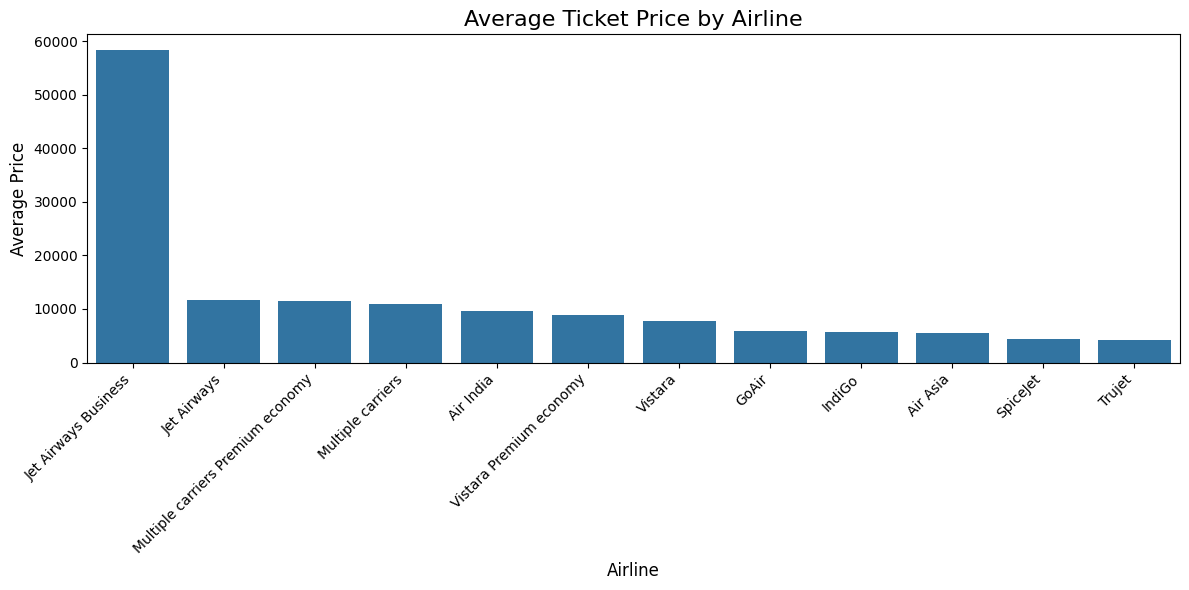

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Airline', y='Price', data=df.groupby('Airline')['Price'].mean().sort_values(ascending=False).reset_index())
plt.title('Average Ticket Price by Airline', fontsize=16)
plt.xlabel('Airline', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Q)Average Ticket Price by Route (Source → Destination)

In [ ]:
df[['Source','Destination']].value_counts()

,,count
Source,Destination,
Delhi,Cochin,4536
Kolkata,Banglore,2871
Banglore,Delhi,2197
Mumbai,Hyderabad,696
Chennai,Kolkata,381


In [ ]:
df.groupby(['Source','Destination'])['Price'].mean().sort_values(ascending=False)

,,Price
Source,Destination,
Delhi,Cochin,10540.113536
Kolkata,Banglore,9158.389411
Banglore,Delhi,8017.464269
Mumbai,Hyderabad,5042.083333
Chennai,Kolkata,4789.892388




*   sql code



Axes(0.125,0.11;0.775x0.77)


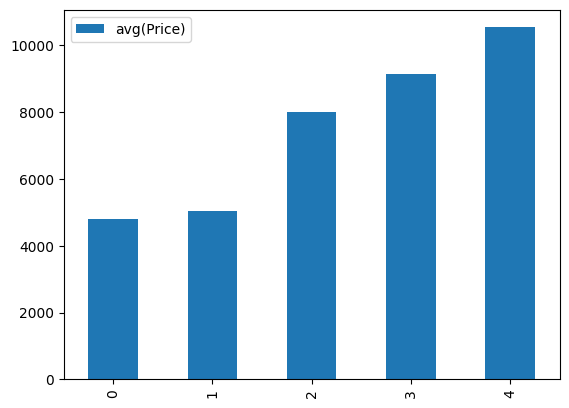

In [ ]:
query = "SELECT Source,Destination,avg(Price) FROM df group by Source,Destination order by avg(Price) "
result_df = sqldf(query, globals())
print(result_df.head().plot(kind='bar'))

<Axes: xlabel='Source,Destination'>

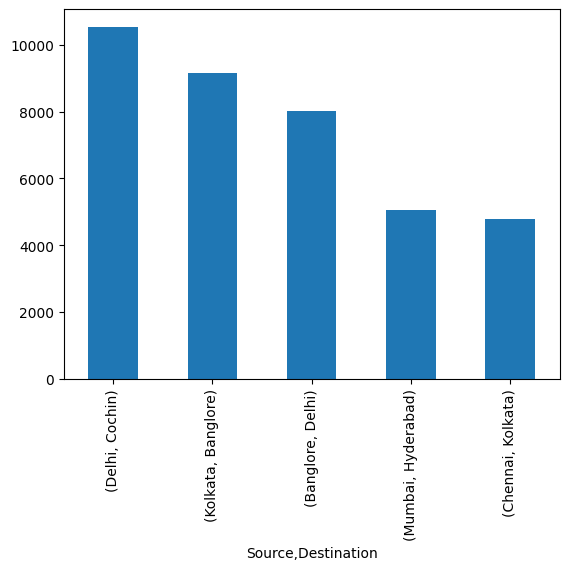

In [ ]:
df.groupby(['Source','Destination'])['Price'].mean().sort_values(ascending=False).plot(kind='bar')


### Q)Average Price by Number of Stops

* python panda   



In [ ]:
df.groupby('no_stop')['Price'].mean().sort_values(ascending=False)

,Price
no_stop,
4,17686.000000
3,13112.000000
2,12712.772219
1,10594.123556
0,5024.900315




*   graph



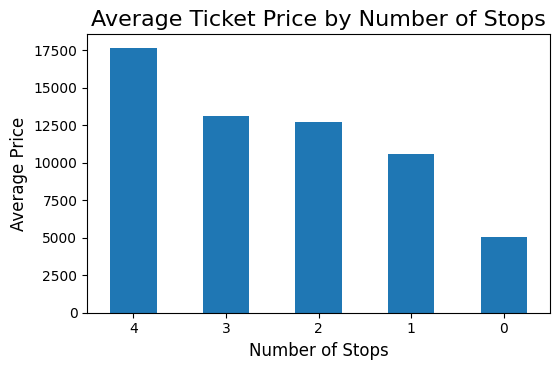

In [ ]:
plt.figure(figsize=(5.7, 3.8))
df.groupby('no_stop')['Price'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Ticket Price by Number of Stops', fontsize=16)
plt.xlabel('Number of Stops', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



*   sql code



In [ ]:
query = "SELECT no_stop,avg(Price) as 'don' FROM df group by no_stop order by don "
result_df = sqldf(query, globals())
print(result_df.head())


   no_stop           don
0        0   5024.900315
1        1  10594.123556
2        2  12712.772219
3        3  13112.000000
4        4  17686.000000




*   Flight Volume by Airline


In [ ]:
df['Airline'].value_counts()

,count
Airline,
Jet Airways,3849
IndiGo,2053
Air India,1750
Multiple carriers,1196
SpiceJet,818
Vistara,479
Air Asia,319
GoAir,194
Multiple carriers Premium economy,13




*   Flight Volume by Source Airport



In [ ]:
query = "SELECT Source,count(Source) as 'don' FROM df group by Source order by count(Source) desc"
result_df = sqldf(query, globals())
print(result_df.head())

     Source   don
0     Delhi  4536
1   Kolkata  2871
2  Banglore  2197
3    Mumbai   696
4   Chennai   381


In [ ]:
df['Source'].value_counts()

,count
Source,
Delhi,4536
Kolkata,2871
Banglore,2197
Mumbai,696
Chennai,381




*   Average Departure Hour by Airline



In [ ]:
df.groupby('Airline')['dep_hour'].mean()

,dep_hour
Airline,
Air Asia,13.996865
Air India,12.321714
GoAir,11.798969
IndiGo,12.215295
Jet Airways,13.363731
Jet Airways Business,10.666667
Multiple carriers,10.062709
Multiple carriers Premium economy,7.769231
SpiceJet,12.282396


In [ ]:
df

,Airline,Source,Destination,Price,Date,Month,Year,journey_time,dep_hour,dep_min,Arr_hour,Arr_min,no_stop
0,IndiGo,Banglore,Delhi,3897,24,3,2019,170,22,20,1,10,0
1,Air India,Kolkata,Banglore,7662,1,5,2019,445,5,50,13,15,2
2,Jet Airways,Delhi,Cochin,13882,9,6,2019,1140,9,25,4,25,2
3,IndiGo,Kolkata,Banglore,6218,12,5,2019,325,18,5,23,30,1
4,IndiGo,Banglore,Delhi,13302,1,3,2019,285,16,50,21,35,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,4107,9,4,2019,150,19,55,22,25,0
10679,Air India,Kolkata,Banglore,4145,27,4,2019,155,20,45,23,20,0
10680,Jet Airways,Banglore,Delhi,7229,27,4,2019,180,8,20,11,20,0
10681,Vistara,Banglore,Delhi,12648,1,3,2019,160,11,30,14,10,0


### Monthly Price Trend





In [ ]:
df.groupby('Month')['Price'].mean().sort_values(ascending=False)

,Price
Month,
3,10670.762027
5,9127.722944
6,8828.796134
4,5770.847081


In [ ]:
df

,Airline,Source,Destination,Price,Date,Month,Year,journey_time,dep_hour,dep_min,Arr_hour,Arr_min,no_stop
0,IndiGo,Banglore,Delhi,3897,24,3,2019,170,22,20,1,10,0
1,Air India,Kolkata,Banglore,7662,1,5,2019,445,5,50,13,15,2
2,Jet Airways,Delhi,Cochin,13882,9,6,2019,1140,9,25,4,25,2
3,IndiGo,Kolkata,Banglore,6218,12,5,2019,325,18,5,23,30,1
4,IndiGo,Banglore,Delhi,13302,1,3,2019,285,16,50,21,35,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,4107,9,4,2019,150,19,55,22,25,0
10679,Air India,Kolkata,Banglore,4145,27,4,2019,155,20,45,23,20,0
10680,Jet Airways,Banglore,Delhi,7229,27,4,2019,180,8,20,11,20,0
10681,Vistara,Banglore,Delhi,12648,1,3,2019,160,11,30,14,10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10681 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Airline       10681 non-null  object
 1   Source        10681 non-null  object
 2   Destination   10681 non-null  object
 3   Price         10681 non-null  int64 
 4   Date          10681 non-null  int64 
 5   Month         10681 non-null  int64 
 6   Year          10681 non-null  int64 
 7   journey_time  10681 non-null  int64 
 8   dep_hour      10681 non-null  int64 
 9   dep_min       10681 non-null  int64 
 10  Arr_hour      10681 non-null  int64 
 11  Arr_min       10681 non-null  int64 
 12  no_stop       10681 non-null  int64 
dtypes: int64(10), object(3)
memory usage: 1.4+ MB


In [ ]:
df.describe()

,Price,Date,Month,Year,journey_time,dep_hour,dep_min,Arr_hour,Arr_min,no_stop
count,10681.000000,10681.000000,10681.000000,10681.0,10681.000000,10681.000000,10681.000000,10681.000000,10681.000000,10681.000000
mean,9086.443123,13.509784,4.708735,2019.0,643.080236,12.490684,24.406891,13.348937,24.687763,0.824080
std,4611.075357,8.479449,1.164345,0.0,507.816377,5.748989,18.767046,6.859590,16.504975,0.675164
min,1759.000000,1.000000,3.000000,2019.0,75.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5277.000000,6.000000,3.000000,2019.0,170.000000,8.000000,5.000000,8.000000,10.000000,0.000000
50%,8372.000000,12.000000,5.000000,2019.0,520.000000,11.000000,25.000000,14.000000,25.000000,1.000000
75%,12373.000000,21.000000,6.000000,2019.0,930.000000,18.000000,40.000000,19.000000,35.000000,1.000000
max,79512.000000,27.000000,6.000000,2019.0,2860.000000,23.000000,55.000000,23.000000,55.000000,4.000000
